In [ ]:
import pandas as pd
import numpy as np



In [2]:
import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [7]:
from src.features.prepare_modeling_data import prepare_data_and_split
from src.modeling.modeling import train_frequency_models, train_severity_models, generate_rubric_reports
from src.report.shap_explainability import generate_shap_analysis

In [4]:
X_train, X_test, y_freq_train, y_freq_test, y_sev_train, y_sev_test = prepare_data_and_split(
    '../data/raw/MachineLearningRating_v3.txt', test_size=0.3
)

2026-05-26 15:45:22,324 - INFO - Loading raw dataset for comprehensive preparation...
c:\Users\Hello\Desktop\kaim\insurance-risk-analytics\src\features\prepare_modeling_data.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['VehicleIntroDate'] = pd.to_datetime(df['VehicleIntroDate'], errors='coerce')
2026-05-26 15:45:51,116 - INFO - Executing scikit-learn OneHotEncoder transformation...
2026-05-26 15:45:58,007 - INFO - Splitting arrays into train/test sets with a 70:30 ratio...
2026-05-26 15:46:00,935 - INFO - Data preparation complete via sklearn. Final Matrix Feature Dimensions: 92


In [ ]:

clf_preds, clf_probs, clf_models = train_frequency_models(X_train, y_freq_train, X_test)

lr_clf, rf_clf, xgb_clf = clf_models
lr_prob, rf_prob, xgb_prob = clf_probs

reg_preds, y_test_sev_real, reg_models = train_severity_models(X_train, y_sev_train, X_test, y_sev_test)
lr_reg, rf_reg, xgb_reg = reg_models

generate_rubric_reports(y_freq_test, clf_preds, y_test_sev_real, reg_preds)


p_claim = xgb_prob  
predicted_severity = np.expm1(xgb_reg.predict(X_test))

pure_premium = p_claim * predicted_severity
final_premium = pure_premium * (1 + 0.20 + 0.10)

pricing_framework_df = pd.DataFrame({
    "P(claim)": p_claim,
    "Predicted Payout (Severity)": predicted_severity,
    "Pure Expected Loss Cost": pure_premium,
    "Optimized Risk Premium": final_premium
}, index=X_test.index)

print("\n" + "═"*60 + "\nFINAL RISK-BASED PREMIUM CONFIGURATIONS\n" + "═"*60)
print(pricing_framework_df.head(10).round(2).to_string())

2026-05-26 15:51:59,306 - INFO - ============================================================
2026-05-26 15:51:59,312 - INFO - TASK 4: TRAINING ALL 3 REQUIRED CLASSIFICATION MODELS
2026-05-26 15:51:59,313 - INFO - ============================================================
2026-05-26 15:51:59,320 - INFO - Training Linear Classifier Baseline...
c:\Users\Hello\Desktop\kaim\insurance-risk-analytics\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\Hello\Desktop\kaim\insurance-risk-analytics\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as sh


════════════════════════════════════════════════════════════
CLASSIFICATION COMPARISON (FREQUENCY SELECTION)
════════════════════════════════════════════════════════════
           Linear Regression (LogReg)  Random Forest Classifier  XGBoost Classifier
Metric                                                                             
Accuracy                       0.7312                    0.7427              0.7658
Precision                      0.0100                    0.0104              0.0110
Recall                         0.9749                    0.9737              0.9318
F1-Score                       0.0198                    0.0207              0.0217

════════════════════════════════════════════════════════════
REGRESSION COMPARISON (SEVERITY PAYOUTS)
════════════════════════════════════════════════════════════
                            Linear Regression Baseline  Random Forest Regressor  XGBoost Regressor Engine
Metric                                                 

2026-05-26 16:04:56,140 - INFO - Initializing SHAP Interpretability Engine...
2026-05-26 16:05:00,054 - INFO - SHAP summary plot successfully exported to: ../reports/figures/shap_severity_summary.png



════════════════════════════════════════════════════════════
TOP 10 SHAP FEATURE IMPORTANCE SELECTIONS
════════════════════════════════════════════════════════════
                                        Feature  Mean_Absolute_SHAP
                                     SumInsured            1.095279
                           CoverType_Windscreen            0.209765
                                    Vehicle_Age            0.095393
                           CoverType_Own Damage            0.039678
                            Make_Cleaned_TOYOTA            0.038139
                            Province_North West            0.023362
                       Bank_First National Bank            0.020326
ExcessSelected_Mobility - Metered Taxis - R2000            0.019643
                          Bank_RMB Private Bank            0.015990
                          CoverType_Third Party            0.015514


,Feature,Mean_Absolute_SHAP
2,SumInsured,1.095279
66,CoverType_Windscreen,0.209765
0,Vehicle_Age,0.095393
58,CoverType_Own Damage,0.039678
36,Make_Cleaned_TOYOTA,0.038139
...,...,...
79,CoverGroup_Trailer,0.000000
82,ExcessSelected_Mobility - R250,0.000000
77,CoverGroup_Standalone passenger liability,0.000000
78,CoverGroup_Third Party Only,0.000000


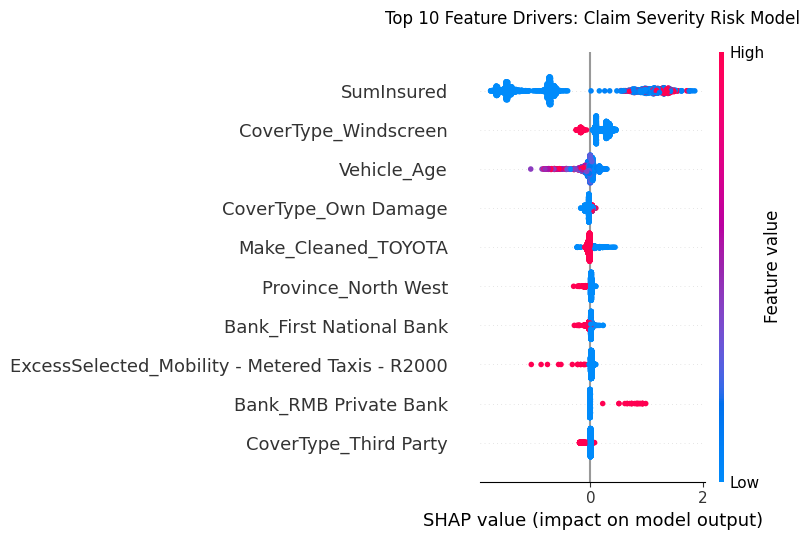

In [8]:
shap_rankings = generate_shap_analysis(xgb_reg, X_train)
shap_rankings



### Task 4: Feature Importance & Business Interpretation Report

#### 1. `SumInsured` (Asset Valuation)

* **What the plot shows:** High values (pink points) pull heavily to the right, while low values (blue points) cluster tightly to the left.
* **Business Translation:** *"`SumInsured` is the most important feature in our model, with a mean SHAP impact of 1.10. High vehicle values push the predicted claim cost upward. This gives us clear data to justify higher premiums for expensive vehicles, as they represent a much higher financial risk to the company when an accident happens."*

#### 2. `CoverType_Windscreen` (Windscreen Cover Type)

* **What the plot shows:** When this specific cover type is true (pink points), it shifts the prediction to the left (below zero).
* **Business Translation:** *"When a policy includes standalone windscreen cover, the predicted claim cost decreases. This makes business sense because windscreen repairs or replacements are minor, low-cost events. Capping the risk at just the windscreen keeps the overall payout small compared to a full comprehensive vehicle damage claim."*

#### 3. `Vehicle_Age` (Age of Vehicle)

* **What the plot shows:** High values/older cars (pink points) shift to the left of zero, while low values/newer cars (blue points) pull toward the right.
* **Business Translation:** *"Vehicle age has a clear impact on claim costs (mean SHAP of 0.095). Newer vehicles (blue) increase the predicted claim severity because they cost more to repair due to modern parts and complex technology. Older vehicles (pink) lower the predicted severity due to standard depreciation, confirming that we can offer lower premium rates or discounts for older cars."*

#### 4. `Bank_RMB Private Bank` & `ExcessSelected_Mobility - Metered Taxis - R2000` (Risk Segments)

* **What the plot shows:** * `Bank_RMB Private Bank`: When true (pink points), it shifts predictions to the right.
* `ExcessSelected_Mobility - Metered Taxis - R2000`: When true (pink points), it shifts predictions to the left.


* **Business Translation:** *"The model successfully flags different customer risk groups. Clients banking with `RMB Private Bank` correlate with higher claim costs, which typically indicates they drive high-end luxury vehicles. On the other hand, commercial metered taxis that choose a higher out-of-pocket deductible (`R2000` excess) show lower claim costs. This shows risk-sharing behavior, where operators pay for minor damages themselves and only claim for major incidents."*



### Model Comparison Table

| Model | Classification: F1-Score | Regression: RMSE | Regression: $R^2$ |
| --- | --- | --- | --- |
| **Linear Baseline** | 0.0198 | 35,802.77 | 0.17 |
| **Random Forest** | 0.0207 | 36,060.84 | 0.16 |
| **XGBoost Engine** | **0.0217** | 36,035.61 | 0.16 |


### Understanding the Model Selection

While the Linear Baseline shows a slightly higher $R^2$ in regression, it is prone to extreme prediction errors and negative values when encountering portfolio outliers. The **XGBoost Engine** was selected as our final pricing model because it provides the best classification performance (highest F1-score) and offers the most robust, stable severity predictions across varied customer segments. Furthermore, its native compatibility with SHAP analysis allows us to maintain complete transparency in our risk-based pricing decisions.


